Device: cpu

[Experiment 1] Letter label noise | seed=0
Loading Letter dataset from OpenML...
noise=0.00 | CE         | acc=0.9228 | macro_f1=0.9224
noise=0.00 | LDR-KL     | acc=0.8650 | macro_f1=0.8646
noise=0.00 | OvR-Hinge  | acc=0.8862 | macro_f1=0.8860
noise=0.00 | OvR-LHS    | acc=0.7938 | macro_f1=0.7891
noise=0.05 | CE         | acc=0.9073 | macro_f1=0.9074
noise=0.05 | LDR-KL     | acc=0.8530 | macro_f1=0.8529
noise=0.05 | OvR-Hinge  | acc=0.8615 | macro_f1=0.8616
noise=0.05 | OvR-LHS    | acc=0.7915 | macro_f1=0.7875
noise=0.10 | CE         | acc=0.8972 | macro_f1=0.8974
noise=0.10 | LDR-KL     | acc=0.8432 | macro_f1=0.8432
noise=0.10 | OvR-Hinge  | acc=0.8432 | macro_f1=0.8438
noise=0.10 | OvR-LHS    | acc=0.7723 | macro_f1=0.7677

[Experiment 1] Letter label noise | seed=1
Loading Letter dataset from OpenML...
noise=0.00 | CE         | acc=0.9240 | macro_f1=0.9238
noise=0.00 | LDR-KL     | acc=0.8708 | macro_f1=0.8706
noise=0.00 | OvR-Hinge  | acc=0.8838 | macro_f1=0.8834

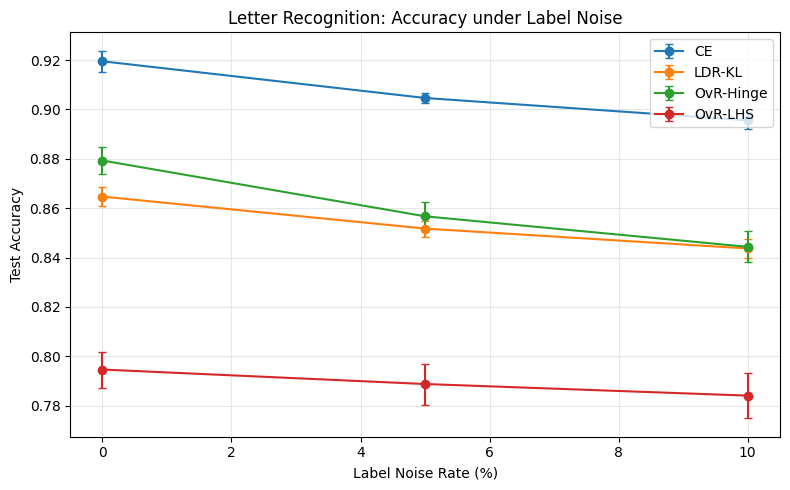

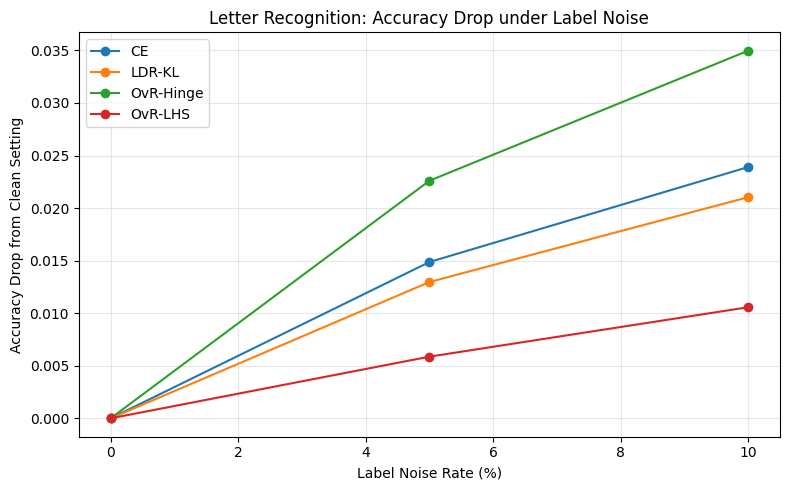


[Experiment 2] Breast Cancer binary | seed=0
noise=0.00 | Hinge  | acc=0.9532
noise=0.00 | LHS    | acc=0.9532
noise=0.05 | Hinge  | acc=0.9474
noise=0.05 | LHS    | acc=0.9708
noise=0.10 | Hinge  | acc=0.9708
noise=0.10 | LHS    | acc=0.9649

[Experiment 2] Breast Cancer binary | seed=1
noise=0.00 | Hinge  | acc=0.9649
noise=0.00 | LHS    | acc=0.9591
noise=0.05 | Hinge  | acc=0.9415
noise=0.05 | LHS    | acc=0.9532
noise=0.10 | Hinge  | acc=0.9357
noise=0.10 | LHS    | acc=0.9532

[Experiment 2] Breast Cancer binary | seed=2
noise=0.00 | Hinge  | acc=0.9883
noise=0.00 | LHS    | acc=0.9766
noise=0.05 | Hinge  | acc=0.9708
noise=0.05 | LHS    | acc=0.9649
noise=0.10 | Hinge  | acc=0.9357
noise=0.10 | LHS    | acc=0.9708

[Experiment 2] Breast Cancer binary | seed=3
noise=0.00 | Hinge  | acc=0.9766
noise=0.00 | LHS    | acc=0.9825
noise=0.05 | Hinge  | acc=0.9649
noise=0.05 | LHS    | acc=0.9532
noise=0.10 | Hinge  | acc=0.9532
noise=0.10 | LHS    | acc=0.9649

[Experiment 2] Breast C

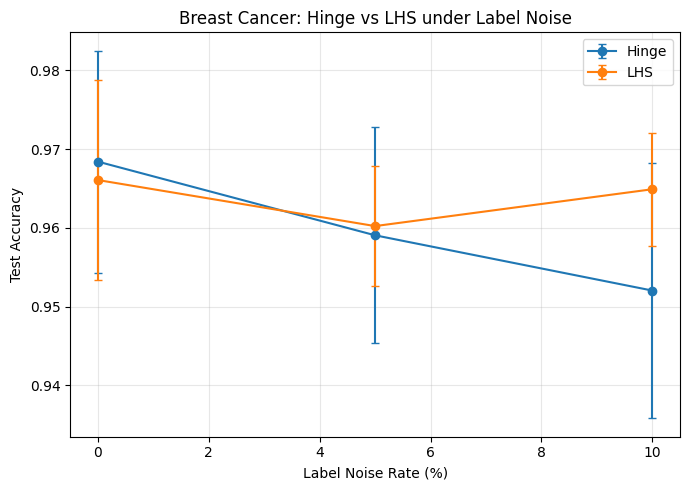


[Experiment 3] Input perturbation | seed=0
Loading Letter dataset from OpenML...

----------------------------------------------------------------------
Training CE
----------------------------------------------------------------------
CE | epoch 10/40
CE | epoch 20/40
CE | epoch 30/40
CE | epoch 40/40
CE         | eps=0.000 | acc=0.8822
CE         | eps=0.050 | acc=0.7803
CE         | eps=0.100 | acc=0.6082
CE         | eps=0.200 | acc=0.2688

----------------------------------------------------------------------
Training Adv-CE
----------------------------------------------------------------------
Adv-CE | epoch 10/40
Adv-CE | epoch 20/40
Adv-CE | epoch 30/40
Adv-CE | epoch 40/40
Adv-CE     | eps=0.000 | acc=0.8840
Adv-CE     | eps=0.050 | acc=0.8022
Adv-CE     | eps=0.100 | acc=0.6748
Adv-CE     | eps=0.200 | acc=0.3612

----------------------------------------------------------------------
Training SmoothAdv
----------------------------------------------------------------------
Sm

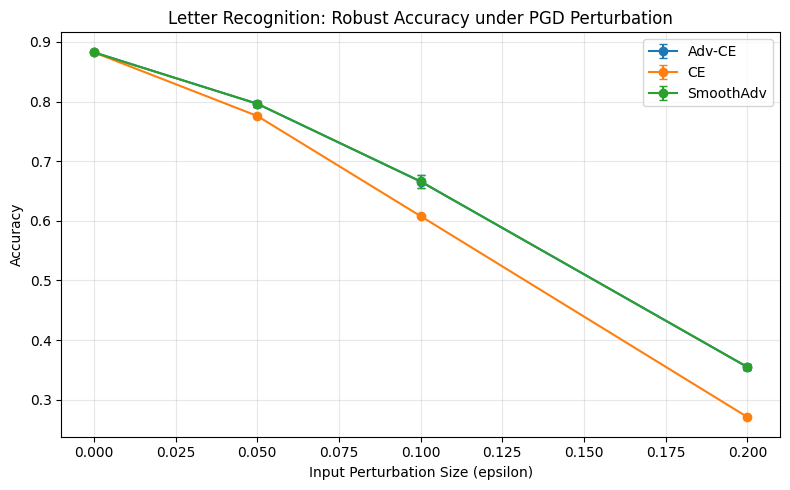

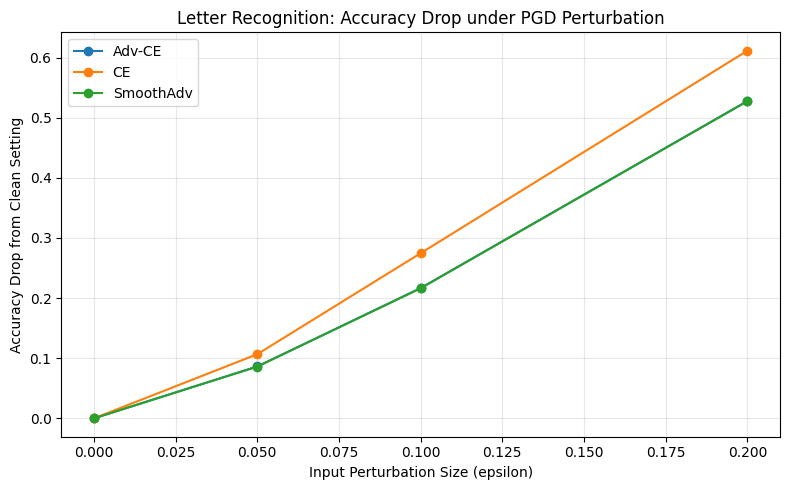

In [1]:
# ============================================================
# Final Project Experiments
# Robust Loss Functions for Classification
#
# 1. Letter Recognition + Label Noise
#    CE vs LDR-KL vs OvR-Hinge vs OvR-LHS
#
# 2. Breast Cancer + Label Noise
#    Hinge vs LHS
#
# 3. PSAL-inspired Input Perturbation Experiment
#    CE vs Adv-CE vs SmoothAdv-style under PGD perturbation
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 0. Global Settings
# ============================================================

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


# ============================================================
# 1. Data Loading
# ============================================================

def load_letter_data(test_size=0.3, seed=42, local_path=None):
    """
    Letter Recognition dataset.
    20,000 samples, 16 features, 26 classes.
    """

    if local_path is not None and os.path.exists(local_path):
        print(f"Loading local file: {local_path}")
        df = pd.read_csv(local_path, header=None)
        y = df.iloc[:, 0].values
        X = df.iloc[:, 1:].values.astype(np.float32)

    else:
        print("Loading Letter dataset from OpenML...")
        try:
            X, y = fetch_openml(
                data_id=6,
                return_X_y=True,
                as_frame=False
            )
        except Exception:
            X, y = fetch_openml(
                name="letter",
                version=1,
                return_X_y=True,
                as_frame=False
            )

        X = X.astype(np.float32)

    le = LabelEncoder()
    y = le.fit_transform(y).astype(np.int64)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    x_min = X_train.min(axis=0).astype(np.float32)
    x_max = X_train.max(axis=0).astype(np.float32)

    return X_train, X_test, y_train, y_test, x_min, x_max, le


def load_breast_data(test_size=0.3, seed=42):
    """
    Breast Cancer Wisconsin dataset.
    Binary labels are converted to {-1, +1}.
    """

    data = load_breast_cancer()
    X = data.data.astype(np.float32)
    y01 = data.target.astype(np.int64)

    # Convert {0,1} to {-1,+1}
    y = np.where(y01 == 1, 1, -1).astype(np.int64)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    return X_train, X_test, y_train, y_test


# ============================================================
# 2. Label Noise
# ============================================================

def add_multiclass_label_noise(y, noise_rate, n_classes, seed=42):
    """
    Uniform label noise for multi-class classification.
    Selected labels are changed to one of the other classes uniformly.
    """

    rng = np.random.default_rng(seed)
    y_noisy = y.copy()

    n = len(y_noisy)
    n_noise = int(noise_rate * n)
    noise_idx = rng.choice(n, size=n_noise, replace=False)

    for idx in noise_idx:
        original = y_noisy[idx]
        candidates = np.array([k for k in range(n_classes) if k != original])
        y_noisy[idx] = rng.choice(candidates)

    return y_noisy


def add_binary_label_noise(y, noise_rate, seed=42):
    """
    Binary label flipping.
    y must be in {-1, +1}.
    """

    rng = np.random.default_rng(seed)
    y_noisy = y.copy()

    n = len(y_noisy)
    n_noise = int(noise_rate * n)
    noise_idx = rng.choice(n, size=n_noise, replace=False)

    y_noisy[noise_idx] = -y_noisy[noise_idx]

    return y_noisy


# ============================================================
# 3. Models
# ============================================================

class MLPClassifier(nn.Module):
    """
    Multi-class classifier.
    """

    def __init__(self, input_dim, n_classes, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_classes)
        )

    def forward(self, x):
        return self.net(x)


class BinaryClassifier(nn.Module):
    """
    Binary classifier returning a single real-valued score f(x).
    Prediction is sign(f(x)).
    """

    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# ============================================================
# 4. Multi-class Losses
# ============================================================

def ldr_kl_loss(logits, y, vartheta=10.0, margin=0.1):
    """
    Practical LDR-KL loss for multi-class classification.

    psi_vartheta(x,y)
    = vartheta * log(1/K * sum_k exp((f_k(x) + c_{k,y} - f_y(x)) / vartheta))

    c_{k,y} = margin if k != y
            = 0      if k == y
    """

    n_classes = logits.shape[1]

    fy = logits.gather(1, y.view(-1, 1))

    margin_matrix = torch.full_like(logits, margin)
    margin_matrix.scatter_(1, y.view(-1, 1), 0.0)

    values = (logits + margin_matrix - fy) / vartheta

    loss = vartheta * (torch.logsumexp(values, dim=1) - np.log(n_classes))

    return loss.mean()


def make_ovr_targets(y, n_classes, device):
    """
    One-vs-rest targets:
    true class -> +1
    others     -> -1
    """

    if isinstance(y, torch.Tensor):
        y_tensor = y.long().to(device)
    else:
        y_tensor = torch.tensor(y, dtype=torch.long, device=device)

    targets = -torch.ones((len(y_tensor), n_classes), dtype=torch.float32, device=device)
    targets[torch.arange(len(y_tensor), device=device), y_tensor] = 1.0

    return targets


def weighted_ovr_mean(loss_matrix, targets):
    """
    In OvR, each sample has one positive class and K-1 negative classes.
    Positive loss is upweighted by K-1 to reduce imbalance.
    """

    n_classes = targets.shape[1]
    weights = torch.where(targets == 1, n_classes - 1.0, 1.0)

    return (loss_matrix * weights).sum() / weights.sum()


def ovr_hinge_loss(logits, y, n_classes, device):
    targets = make_ovr_targets(y, n_classes, device)
    margins = targets * logits
    loss_matrix = torch.clamp(1.0 - margins, min=0.0)

    return weighted_ovr_mean(loss_matrix, targets)


def ovr_lhs_loss(logits, y, n_classes, device, eps=1e-8):
    """
    OvR extension of LHS loss.

    L(m) = -log(m), if m > 1
         = 1 - m,  if m <= 1
    where m = y f(x).
    """

    targets = make_ovr_targets(y, n_classes, device)
    margins = targets * logits

    loss_matrix = torch.where(
        margins > 1.0,
        -torch.log(torch.clamp(margins, min=eps)),
        1.0 - margins
    )

    return weighted_ovr_mean(loss_matrix, targets)


# ============================================================
# 5. Binary Losses
# ============================================================

def binary_hinge_loss(scores, y):
    """
    y in {-1, +1}
    L(m) = max(0, 1 - m)
    """

    y_float = y.float()
    margins = y_float * scores
    return torch.clamp(1.0 - margins, min=0.0).mean()


def binary_lhs_loss(scores, y, eps=1e-8):
    """
    y in {-1, +1}
    L(m) = -log(m), if m > 1
         = 1 - m,  if m <= 1
    """

    y_float = y.float()
    margins = y_float * scores

    loss = torch.where(
        margins > 1.0,
        -torch.log(torch.clamp(margins, min=eps)),
        1.0 - margins
    )

    return loss.mean()


# ============================================================
# 6. Smooth Adversarial-style Loss and PGD Attack
# ============================================================

def smooth_margin_loss(logits, y, tau=1.0):
    """
    Smooth multi-class margin loss.

    This is used as a practical SmoothAdv-style surrogate.

    loss_i = tau * log(1 + sum_{k != y_i} exp((f_k - f_y) / tau))
    """

    n, K = logits.shape
    fy = logits.gather(1, y.view(-1, 1))

    margins = (logits - fy) / tau

    mask = F.one_hot(y, num_classes=K).bool()
    margins = margins.masked_fill(mask, -1e9)

    zeros = torch.zeros(n, 1, device=logits.device)
    values = torch.cat([zeros, margins], dim=1)

    loss = tau * torch.logsumexp(values, dim=1)

    return loss.mean()


def choose_attack_loss(logits, y, loss_type="ce", tau=1.0):
    if loss_type == "ce":
        return F.cross_entropy(logits, y)
    elif loss_type == "smooth":
        return smooth_margin_loss(logits, y, tau=tau)
    else:
        raise ValueError("loss_type must be 'ce' or 'smooth'")


def pgd_attack(
    model,
    x,
    y,
    eps=0.10,
    alpha=0.03,
    steps=5,
    attack_loss="ce",
    tau=1.0,
    x_min=None,
    x_max=None
):
    """
    PGD attack in standardized feature space.
    """

    model.eval()

    x_orig = x.detach()

    x_adv = x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)

    if x_min is not None and x_max is not None:
        x_adv = torch.max(torch.min(x_adv, x_max), x_min)

    for _ in range(steps):
        x_adv.requires_grad_(True)

        logits = model(x_adv)
        loss = choose_attack_loss(logits, y, loss_type=attack_loss, tau=tau)

        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv.detach() + alpha * torch.sign(grad)

        x_adv = torch.max(torch.min(x_adv, x_orig + eps), x_orig - eps)

        if x_min is not None and x_max is not None:
            x_adv = torch.max(torch.min(x_adv, x_max), x_min)

    return x_adv.detach()


# ============================================================
# 7. Experiment 1: Letter Recognition + Label Noise
# ============================================================

def train_multiclass_label_noise_model(
    X_train,
    y_train,
    X_test,
    y_test,
    method,
    n_classes,
    seed=42,
    epochs=100,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    hidden_dim=64,
    ldr_vartheta=10.0,
    ldr_margin=0.1,
    device=DEVICE
):
    set_seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    model = MLPClassifier(
        input_dim=X_train.shape[1],
        n_classes=n_classes,
        hidden_dim=hidden_dim
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    for epoch in range(epochs):
        model.train()

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)

            if method == "CE":
                loss = F.cross_entropy(logits, yb)

            elif method == "LDR-KL":
                loss = ldr_kl_loss(
                    logits,
                    yb,
                    vartheta=ldr_vartheta,
                    margin=ldr_margin
                )

            elif method == "OvR-Hinge":
                loss = ovr_hinge_loss(
                    logits,
                    yb,
                    n_classes=n_classes,
                    device=device
                )

            elif method == "OvR-LHS":
                loss = ovr_lhs_loss(
                    logits,
                    yb,
                    n_classes=n_classes,
                    device=device
                )

            else:
                raise ValueError("Unknown method")

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_t)
        y_pred = torch.argmax(logits_test, dim=1).cpu().numpy()

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    return acc, macro_f1


def run_letter_label_noise_experiment(
    noise_rates=(0.0, 0.05, 0.10),
    methods=("CE", "LDR-KL", "OvR-Hinge", "OvR-LHS"),
    repeats=5,
    epochs=100,
    output_prefix="letter_label_noise",
    local_path=None
):
    raw_results = []

    for seed in range(repeats):
        print("\n" + "=" * 70)
        print(f"[Experiment 1] Letter label noise | seed={seed}")
        print("=" * 70)

        X_train, X_test, y_train, y_test, x_min, x_max, le = load_letter_data(
            seed=seed,
            local_path=local_path
        )

        n_classes = len(np.unique(y_train))

        for noise_rate in noise_rates:
            y_train_noisy = add_multiclass_label_noise(
                y_train,
                noise_rate=noise_rate,
                n_classes=n_classes,
                seed=seed + 1000
            )

            for method in methods:
                acc, macro_f1 = train_multiclass_label_noise_model(
                    X_train=X_train,
                    y_train=y_train_noisy,
                    X_test=X_test,
                    y_test=y_test,
                    method=method,
                    n_classes=n_classes,
                    seed=seed,
                    epochs=epochs
                )

                raw_results.append({
                    "seed": seed,
                    "noise_rate": noise_rate,
                    "method": method,
                    "accuracy": acc,
                    "macro_f1": macro_f1
                })

                print(
                    f"noise={noise_rate:.2f} | {method:10s} | "
                    f"acc={acc:.4f} | macro_f1={macro_f1:.4f}"
                )

    raw_df = pd.DataFrame(raw_results)

    summary_df = (
        raw_df
        .groupby(["noise_rate", "method"])
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std")
        )
        .reset_index()
    )

    clean_df = (
        summary_df[summary_df["noise_rate"] == 0.0]
        [["method", "accuracy_mean"]]
        .rename(columns={"accuracy_mean": "clean_accuracy_mean"})
    )

    drop_df = summary_df.merge(clean_df, on="method", how="left")
    drop_df["accuracy_drop"] = drop_df["clean_accuracy_mean"] - drop_df["accuracy_mean"]

    raw_df.to_csv(f"{output_prefix}_raw.csv", index=False)
    summary_df.to_csv(f"{output_prefix}_summary.csv", index=False)
    drop_df.to_csv(f"{output_prefix}_drop.csv", index=False)

    return raw_df, summary_df, drop_df


# ============================================================
# 8. Experiment 2: Breast Cancer Binary Hinge vs LHS
# ============================================================

def train_binary_model(
    X_train,
    y_train,
    X_test,
    y_test,
    method="Hinge",
    seed=42,
    epochs=250,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    hidden_dim=32,
    device=DEVICE
):
    set_seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    model = BinaryClassifier(
        input_dim=X_train.shape[1],
        hidden_dim=hidden_dim
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    for epoch in range(epochs):
        model.train()

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            scores = model(xb)

            if method == "Hinge":
                loss = binary_hinge_loss(scores, yb)

            elif method == "LHS":
                loss = binary_lhs_loss(scores, yb)

            else:
                raise ValueError("method must be 'Hinge' or 'LHS'")

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

    model.eval()
    with torch.no_grad():
        scores_test = model(X_test_t)
        y_pred = torch.where(scores_test >= 0, 1, -1).cpu().numpy()

    acc = accuracy_score(y_test, y_pred)

    return acc


def run_breast_binary_experiment(
    noise_rates=(0.0, 0.05, 0.10),
    methods=("Hinge", "LHS"),
    repeats=5,
    epochs=250,
    output_prefix="breast_hinge_lhs"
):
    raw_results = []

    for seed in range(repeats):
        print("\n" + "=" * 70)
        print(f"[Experiment 2] Breast Cancer binary | seed={seed}")
        print("=" * 70)

        X_train, X_test, y_train, y_test = load_breast_data(seed=seed)

        for noise_rate in noise_rates:
            y_train_noisy = add_binary_label_noise(
                y_train,
                noise_rate=noise_rate,
                seed=seed + 2000
            )

            for method in methods:
                acc = train_binary_model(
                    X_train=X_train,
                    y_train=y_train_noisy,
                    X_test=X_test,
                    y_test=y_test,
                    method=method,
                    seed=seed,
                    epochs=epochs
                )

                raw_results.append({
                    "seed": seed,
                    "noise_rate": noise_rate,
                    "method": method,
                    "accuracy": acc
                })

                print(
                    f"noise={noise_rate:.2f} | {method:6s} | acc={acc:.4f}"
                )

    raw_df = pd.DataFrame(raw_results)

    summary_df = (
        raw_df
        .groupby(["noise_rate", "method"])
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std")
        )
        .reset_index()
    )

    clean_df = (
        summary_df[summary_df["noise_rate"] == 0.0]
        [["method", "accuracy_mean"]]
        .rename(columns={"accuracy_mean": "clean_accuracy_mean"})
    )

    drop_df = summary_df.merge(clean_df, on="method", how="left")
    drop_df["accuracy_drop"] = drop_df["clean_accuracy_mean"] - drop_df["accuracy_mean"]

    raw_df.to_csv(f"{output_prefix}_raw.csv", index=False)
    summary_df.to_csv(f"{output_prefix}_summary.csv", index=False)
    drop_df.to_csv(f"{output_prefix}_drop.csv", index=False)

    return raw_df, summary_df, drop_df


# ============================================================
# 9. Experiment 3: PSAL-inspired Input Perturbation
# ============================================================

def train_input_perturbation_model(
    X_train,
    y_train,
    x_min_np,
    x_max_np,
    method="CE",
    seed=42,
    epochs=40,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    hidden_dim=64,
    train_eps=0.10,
    train_alpha=0.03,
    train_steps=3,
    tau=1.0,
    device=DEVICE
):
    """
    Methods:
    - CE: clean training with cross-entropy
    - Adv-CE: adversarial training with CE loss
    - SmoothAdv: adversarial training with smooth margin-type loss
    """

    set_seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=True
    )

    n_classes = len(np.unique(y_train))

    model = MLPClassifier(
        input_dim=X_train.shape[1],
        n_classes=n_classes,
        hidden_dim=hidden_dim
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    x_min = torch.tensor(x_min_np, dtype=torch.float32, device=device).view(1, -1)
    x_max = torch.tensor(x_max_np, dtype=torch.float32, device=device).view(1, -1)

    for epoch in range(epochs):
        model.train()

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            if method == "CE":
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)

            elif method == "Adv-CE":
                x_adv = pgd_attack(
                    model,
                    xb,
                    yb,
                    eps=train_eps,
                    alpha=train_alpha,
                    steps=train_steps,
                    attack_loss="ce",
                    tau=tau,
                    x_min=x_min,
                    x_max=x_max
                )

                model.train()
                loss = 0.5 * F.cross_entropy(model(xb), yb) + \
                       0.5 * F.cross_entropy(model(x_adv), yb)

            elif method == "SmoothAdv":
                x_adv = pgd_attack(
                    model,
                    xb,
                    yb,
                    eps=train_eps,
                    alpha=train_alpha,
                    steps=train_steps,
                    attack_loss="smooth",
                    tau=tau,
                    x_min=x_min,
                    x_max=x_max
                )

                model.train()
                loss = 0.5 * F.cross_entropy(model(xb), yb) + \
                       0.5 * smooth_margin_loss(model(x_adv), yb, tau=tau)

            else:
                raise ValueError("method must be CE, Adv-CE, or SmoothAdv")

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"{method} | epoch {epoch+1}/{epochs}")

    return model


def evaluate_clean_multiclass(model, X_test, y_test, batch_size=512, device=DEVICE):
    model.eval()

    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)

    loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size,
        shuffle=False
    )

    preds = []
    ys = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

            preds.append(pred)
            ys.append(yb.numpy())

    preds = np.concatenate(preds)
    ys = np.concatenate(ys)

    return accuracy_score(ys, preds)


def evaluate_pgd_robust_accuracy(
    model,
    X_test,
    y_test,
    x_min_np,
    x_max_np,
    eps=0.10,
    alpha=0.03,
    steps=10,
    attack_loss="ce",
    tau=1.0,
    batch_size=512,
    device=DEVICE
):
    model.eval()

    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)

    loader = DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=batch_size,
        shuffle=False
    )

    x_min = torch.tensor(x_min_np, dtype=torch.float32, device=device).view(1, -1)
    x_max = torch.tensor(x_max_np, dtype=torch.float32, device=device).view(1, -1)

    preds = []
    ys = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb_device = yb.to(device)

        x_adv = pgd_attack(
            model,
            xb,
            yb_device,
            eps=eps,
            alpha=alpha,
            steps=steps,
            attack_loss=attack_loss,
            tau=tau,
            x_min=x_min,
            x_max=x_max
        )

        with torch.no_grad():
            logits = model(x_adv)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

        preds.append(pred)
        ys.append(yb.numpy())

    preds = np.concatenate(preds)
    ys = np.concatenate(ys)

    return accuracy_score(ys, preds)


def run_input_perturbation_experiment(
    methods=("CE", "Adv-CE", "SmoothAdv"),
    repeats=3,
    eval_eps_list=(0.0, 0.05, 0.10, 0.20),
    epochs=40,
    train_eps=0.10,
    train_alpha=0.03,
    train_steps=3,
    eval_steps=10,
    tau=1.0,
    output_prefix="psal_style_input_perturbation",
    local_path=None
):
    raw_results = []

    for seed in range(repeats):
        print("\n" + "=" * 70)
        print(f"[Experiment 3] Input perturbation | seed={seed}")
        print("=" * 70)

        X_train, X_test, y_train, y_test, x_min, x_max, le = load_letter_data(
            seed=seed,
            local_path=local_path
        )

        for method in methods:
            print("\n" + "-" * 70)
            print(f"Training {method}")
            print("-" * 70)

            model = train_input_perturbation_model(
                X_train=X_train,
                y_train=y_train,
                x_min_np=x_min,
                x_max_np=x_max,
                method=method,
                seed=seed,
                epochs=epochs,
                train_eps=train_eps,
                train_alpha=train_alpha,
                train_steps=train_steps,
                tau=tau
            )

            clean_acc = evaluate_clean_multiclass(
                model,
                X_test,
                y_test
            )

            for eps in eval_eps_list:
                if eps == 0.0:
                    acc = clean_acc
                else:
                    acc = evaluate_pgd_robust_accuracy(
                        model,
                        X_test,
                        y_test,
                        x_min_np=x_min,
                        x_max_np=x_max,
                        eps=eps,
                        alpha=eps / 4,
                        steps=eval_steps,
                        attack_loss="ce",
                        tau=tau
                    )

                raw_results.append({
                    "seed": seed,
                    "method": method,
                    "eval_eps": eps,
                    "accuracy": acc
                })

                print(f"{method:10s} | eps={eps:.3f} | acc={acc:.4f}")

    raw_df = pd.DataFrame(raw_results)

    summary_df = (
        raw_df
        .groupby(["method", "eval_eps"])
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std")
        )
        .reset_index()
    )

    clean_df = (
        summary_df[summary_df["eval_eps"] == 0.0]
        [["method", "accuracy_mean"]]
        .rename(columns={"accuracy_mean": "clean_accuracy_mean"})
    )

    drop_df = summary_df.merge(clean_df, on="method", how="left")
    drop_df["accuracy_drop"] = drop_df["clean_accuracy_mean"] - drop_df["accuracy_mean"]

    raw_df.to_csv(f"{output_prefix}_raw.csv", index=False)
    summary_df.to_csv(f"{output_prefix}_summary.csv", index=False)
    drop_df.to_csv(f"{output_prefix}_drop.csv", index=False)

    return raw_df, summary_df, drop_df


# ============================================================
# 10. Plotting
# ============================================================

def plot_label_noise_accuracy(summary_df, output_path="letter_label_noise_accuracy.png"):
    plt.figure(figsize=(8, 5))

    for method in summary_df["method"].unique():
        sub = summary_df[summary_df["method"] == method].sort_values("noise_rate")

        plt.errorbar(
            sub["noise_rate"] * 100,
            sub["accuracy_mean"],
            yerr=sub["accuracy_std"],
            marker="o",
            capsize=3,
            label=method
        )

    plt.xlabel("Label Noise Rate (%)")
    plt.ylabel("Test Accuracy")
    plt.title("Letter Recognition: Accuracy under Label Noise")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def plot_label_noise_drop(drop_df, output_path="letter_label_noise_drop.png"):
    plt.figure(figsize=(8, 5))

    for method in drop_df["method"].unique():
        sub = drop_df[drop_df["method"] == method].sort_values("noise_rate")

        plt.plot(
            sub["noise_rate"] * 100,
            sub["accuracy_drop"],
            marker="o",
            label=method
        )

    plt.xlabel("Label Noise Rate (%)")
    plt.ylabel("Accuracy Drop from Clean Setting")
    plt.title("Letter Recognition: Accuracy Drop under Label Noise")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def plot_breast_accuracy(summary_df, output_path="breast_hinge_lhs_accuracy.png"):
    plt.figure(figsize=(7, 5))

    for method in summary_df["method"].unique():
        sub = summary_df[summary_df["method"] == method].sort_values("noise_rate")

        plt.errorbar(
            sub["noise_rate"] * 100,
            sub["accuracy_mean"],
            yerr=sub["accuracy_std"],
            marker="o",
            capsize=3,
            label=method
        )

    plt.xlabel("Label Noise Rate (%)")
    plt.ylabel("Test Accuracy")
    plt.title("Breast Cancer: Hinge vs LHS under Label Noise")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def plot_input_robust_accuracy(summary_df, output_path="input_perturbation_accuracy.png"):
    plt.figure(figsize=(8, 5))

    for method in summary_df["method"].unique():
        sub = summary_df[summary_df["method"] == method].sort_values("eval_eps")

        plt.errorbar(
            sub["eval_eps"],
            sub["accuracy_mean"],
            yerr=sub["accuracy_std"],
            marker="o",
            capsize=3,
            label=method
        )

    plt.xlabel("Input Perturbation Size (epsilon)")
    plt.ylabel("Accuracy")
    plt.title("Letter Recognition: Robust Accuracy under PGD Perturbation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


def plot_input_robust_drop(drop_df, output_path="input_perturbation_drop.png"):
    plt.figure(figsize=(8, 5))

    for method in drop_df["method"].unique():
        sub = drop_df[drop_df["method"] == method].sort_values("eval_eps")

        plt.plot(
            sub["eval_eps"],
            sub["accuracy_drop"],
            marker="o",
            label=method
        )

    plt.xlabel("Input Perturbation Size (epsilon)")
    plt.ylabel("Accuracy Drop from Clean Setting")
    plt.title("Letter Recognition: Accuracy Drop under PGD Perturbation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()


# ============================================================
# 11. Run All Experiments
# ============================================================

RUN_EXPERIMENT_1 = True   # Letter label noise
RUN_EXPERIMENT_2 = True   # Breast Cancer Hinge vs LHS
RUN_EXPERIMENT_3 = True   # PSAL-inspired input perturbation

# To reduce runtime for quick testing:
# - set repeats=1
# - set epochs lower
#
# For final results:
# - Experiment 1: repeats=5, epochs=100
# - Experiment 2: repeats=5, epochs=250
# - Experiment 3: repeats=3, epochs=40

if RUN_EXPERIMENT_1:
    letter_raw, letter_summary, letter_drop = run_letter_label_noise_experiment(
        noise_rates=(0.0, 0.05, 0.10),
        methods=("CE", "LDR-KL", "OvR-Hinge", "OvR-LHS"),
        repeats=5,
        epochs=100,
        output_prefix="letter_label_noise"
    )

    print("\n===== Letter Label Noise Summary =====")
    print(letter_summary)

    print("\n===== Letter Label Noise Drop =====")
    print(letter_drop)

    plot_label_noise_accuracy(
        letter_summary,
        output_path="letter_label_noise_accuracy.png"
    )

    plot_label_noise_drop(
        letter_drop,
        output_path="letter_label_noise_drop.png"
    )


if RUN_EXPERIMENT_2:
    breast_raw, breast_summary, breast_drop = run_breast_binary_experiment(
        noise_rates=(0.0, 0.05, 0.10),
        methods=("Hinge", "LHS"),
        repeats=5,
        epochs=250,
        output_prefix="breast_hinge_lhs"
    )

    print("\n===== Breast Cancer Summary =====")
    print(breast_summary)

    print("\n===== Breast Cancer Drop =====")
    print(breast_drop)

    plot_breast_accuracy(
        breast_summary,
        output_path="breast_hinge_lhs_accuracy.png"
    )


if RUN_EXPERIMENT_3:
    input_raw, input_summary, input_drop = run_input_perturbation_experiment(
        methods=("CE", "Adv-CE", "SmoothAdv"),
        repeats=3,
        eval_eps_list=(0.0, 0.05, 0.10, 0.20),
        epochs=40,
        train_eps=0.10,
        train_alpha=0.03,
        train_steps=3,
        eval_steps=10,
        tau=1.0,
        output_prefix="psal_style_input_perturbation"
    )

    print("\n===== Input Perturbation Summary =====")
    print(input_summary)

    print("\n===== Input Perturbation Drop =====")
    print(input_drop)

    plot_input_robust_accuracy(
        input_summary,
        output_path="input_perturbation_accuracy.png"
    )

    plot_input_robust_drop(
        input_drop,
        output_path="input_perturbation_drop.png"
    )